# 01 · Data & Labeling

ABSA support-ticket router — **data pipeline**: source cleaning → locked taxonomy →
weak aspect-tag prior → LLM labeling (20k, Qwen3-4B) → human audit.

> Heavy cells (LLM labeling) keep their full code but **guard-load** the produced
> artifact so this notebook executes in seconds, not hours.

## Setup

In [1]:
import os, sys, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = os.path.abspath('..'); sys.path.insert(0, ROOT)
from taxonomy import ASPECTS, ASPECT_DEFINITIONS, QUEUES, SENTIMENT_LABELS, ASPECT_MAP, map_aspects
DATA = os.path.join(ROOT, 'data')

## 1 · Source datasets → clean

Three English-filtered IT-support-ticket CSVs (Tobias Bueck, HuggingFace). We
concat, clean text, drop junk/dupes, and map the noisy `tag_*` columns to a 9-aspect
prior. Text is LLM-synthetic (a stated limitation).

In [2]:
import glob, re
def clean_text(s):
    if not isinstance(s, str): return ''
    s = s.replace('\\n',' ').replace('\\r',' ')
    return re.sub(r'\s+',' ', s).strip()

if os.path.exists(f'{DATA}/tickets_clean.csv'):
    clean = pd.read_csv(f'{DATA}/tickets_clean.csv')
    print('loaded existing tickets_clean.csv:', clean.shape)
else:
    TAGS = [f'tag_{i}' for i in range(1,10)]
    frames=[]
    for f in sorted(glob.glob(f'{ROOT}/datasets/*.csv')):
        d = pd.read_csv(f)
        for t in TAGS:
            if t not in d: d[t] = pd.NA
        frames.append(d[['body','queue','type','priority']+TAGS])
    clean = pd.concat(frames, ignore_index=True)
    clean['body'] = clean['body'].apply(clean_text)
    clean = clean[clean.body.str.len()>=30].drop_duplicates('body').reset_index(drop=True)
    clean['aspect_tags'] = clean.apply(lambda r: '|'.join(map_aspects([r[t] for t in TAGS])), axis=1)
    clean.insert(0,'ticket_id', range(1, len(clean)+1))
    clean = clean[['ticket_id','body','queue','type','priority','aspect_tags']]
    clean.to_csv(f'{DATA}/tickets_clean.csv', index=False)
print('clean tickets:', len(clean))
clean.head(3)

loaded existing tickets_clean.csv: (24934, 8)
clean tickets: 24934


,ticket_id,body,queue,type,priority,aspect_tags,aspect_sentiment,n_chars
0,1,"Dear Customer Support Team, I am writing to re...",Technical Support,Incident,high,account|performance,NaN,538
1,2,"Dear Customer Support Team, I hope this messag...",Returns and Exchanges,Request,medium,feature,NaN,528
2,3,"Dear Customer Support Team, I hope this messag...",Billing and Payments,Request,low,account|billing|feature,NaN,596


### Routing label (`queue`) distribution

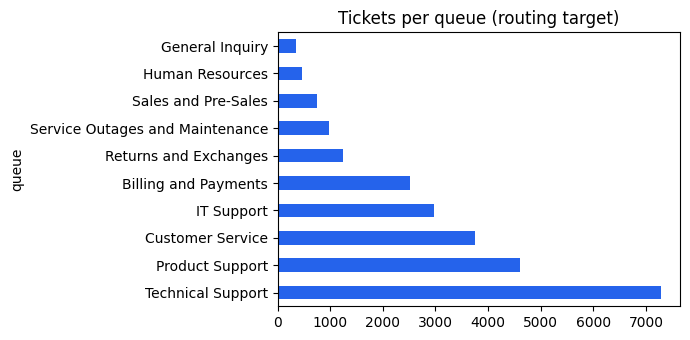

In [3]:
clean.queue.value_counts().plot(kind='barh', figsize=(7,3.5), color='#2563eb')
plt.title('Tickets per queue (routing target)'); plt.tight_layout(); plt.show()

## 2 · Locked taxonomy

9 aspects × 3-class sentiment (`not_present / negative / neutral`). `positive` was
dropped — support tickets are ~never genuine praise; the LLM's "positive" cells were
~100% neutral inquiries.

In [4]:
pd.DataFrame({'aspect':ASPECTS, 'definition':[ASPECT_DEFINITIONS[a] for a in ASPECTS]})

,aspect,definition
0,billing,"Charges, invoices, payments, refunds, pricing,..."
1,account,"Login, passwords, authentication, account acce..."
2,performance,"Speed, crashes, outages, downtime, latency, di..."
3,security,"Vulnerabilities, malware/virus, breaches, data..."
4,bug,Defects / errors / unexpected behavior / confl...
5,feature,"Capabilities, integrations, API, documentation..."
6,network,"Connectivity, VPN, connection drops, server re..."
7,hardware,"Physical devices, equipment, drivers, firmware..."
8,software,"Application install/setup, software update/upg..."


## 3 · LLM labeling — Qwen3-4B (4-bit), sentence-level

**Heavy step (~hours for 20k).** The labeler builds a strict-JSON prompt per ticket
(system + few-shot teaching the neg/neutral boundary) and parses the 9-aspect verdict.
The full, runnable labeler is below; it is **guard-wrapped** so it only runs if the
labeled artifact is missing — otherwise we load the produced file.

In [5]:
# ---------- FULL Qwen3-4B labeler (runs only if labeled_llm.csv is absent) ----------
import json, re
DEFS = "\n".join(f"- {a}: {ASPECT_DEFINITIONS[a]}" for a in ASPECTS)
SYSTEM = (
    "You are an expert support-ticket annotator. For EACH aspect decide whether it is "
    "mentioned and the customer sentiment toward it.\n\n"
    f"Aspects:\n{DEFS}\n\n"
    "Output exactly one of not_present/negative/neutral per aspect. "
    "negative=problem/complaint; neutral=inquiry/request/factual; not_present=not mentioned. "
    "Tickets are almost never positive: 'enhance/improve/optimize' is a request (neutral). "
    "Respond ONLY with a JSON object mapping each aspect name to its label.")

def parse(text):
    m = re.search(r"\{.*\}", text, re.DOTALL)
    if not m: return None
    try: obj = json.loads(m.group(0))
    except Exception: return None
    return {a: (str(obj.get(a,'not_present')).strip().lower()
                if str(obj.get(a,'not_present')).strip().lower() in SENTIMENT_LABELS
                else 'not_present') for a in ASPECTS}

def run_labeler(df_to_label):
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                             bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
    tok = AutoTokenizer.from_pretrained('Qwen/Qwen3-4B')
    model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen3-4B', quantization_config=bnb,
                                                 device_map={'': 0}, dtype=torch.bfloat16).eval()
    out = []
    for body in df_to_label.body:
        msgs = [{'role':'system','content':SYSTEM},
                {'role':'user','content':f'Ticket:\n"""{str(body)[:1200]}"""\nReturn JSON keys: {ASPECTS}'}]
        prompt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False)
        enc = tok(prompt, return_tensors='pt', truncation=True, max_length=1600).to(model.device)
        with torch.no_grad():
            gen = model.generate(**enc, max_new_tokens=160, do_sample=False, pad_token_id=tok.eos_token_id)
        res = parse(tok.decode(gen[0][enc['input_ids'].shape[1]:], skip_special_tokens=True)) or {a:'not_present' for a in ASPECTS}
        out.append(res)
    return out

if os.path.exists(f'{DATA}/labeled_llm.csv'):
    lab = pd.read_csv(f'{DATA}/labeled_llm.csv')
    print('loaded existing labels (skipped ~hours of Qwen inference)')
else:
    pool = pd.read_csv(f'{DATA}/label_pool.csv')   # stratified sample to label
    recs = run_labeler(pool)
    for a in ASPECTS: pool[f'asp_{a}'] = [r[a] for r in recs]
    pool['label_source'] = 'llm-qwen3-4b-4bit'
    pool.to_csv(f'{DATA}/labeled_llm.csv', index=False); lab = pool

assert (lab.label_source == 'llm-qwen3-4b-4bit').all()
print('labeled tickets:', len(lab), '| all 3-class valid:',
      all(lab[f'asp_{a}'].fillna('not_present').isin(SENTIMENT_LABELS).all() for a in ASPECTS))
dist = pd.DataFrame({a: lab[f'asp_{a}'].fillna('not_present').value_counts() for a in ASPECTS}).T
dist[['negative','neutral','not_present']].fillna(0).astype(int)

loaded existing labels (skipped ~hours of Qwen inference)
labeled tickets: 20000 | all 3-class valid: True


,negative,neutral,not_present
billing,847,92,19061
account,694,313,18993
performance,5946,386,13668
security,2841,112,17047
bug,4070,52,15878
feature,920,3161,15919
network,2238,225,17537
hardware,2290,192,17518
software,9014,1879,9107


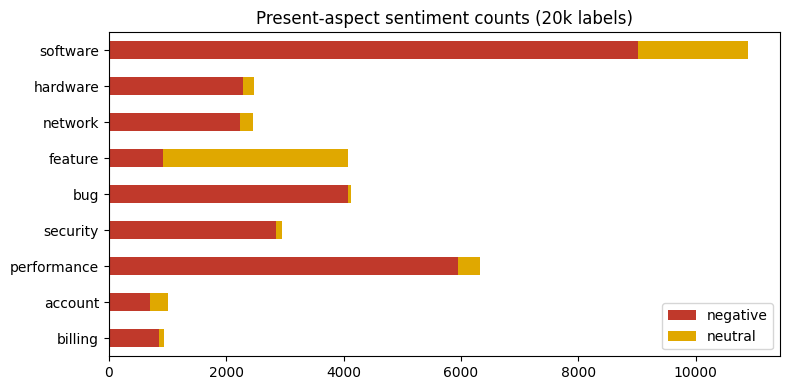

In [6]:
dist[['negative','neutral']].fillna(0).plot(kind='barh', stacked=True, figsize=(8,4),
    color=['#c0392b','#e0a800'], title='Present-aspect sentiment counts (20k labels)')
plt.tight_layout(); plt.show()

## 4 · Human audit (80 tickets, blind)

A blind expert pass vs the LLM labels measures label quality.

In [7]:
# agreement reproduced from the audit artifacts
sheet = pd.read_csv(f'{DATA}/audit_sheet.csv'); key = pd.read_csv(f'{DATA}/audit_key.csv')
sheet = sheet.set_index('ticket_id'); key = key.set_index('ticket_id')
ids = sheet.index.intersection(key.index)
def norm(v):
    v=str(v).strip().lower(); return 'not_present' if v in ('','nan','none') else v
pairs=[(norm(sheet.at[t,f'human_{a}']), norm(key.at[t,f'llm_{a}'])) for t in ids for a in ASPECTS]
import numpy as np
h=np.array([x[0] for x in pairs]); l=np.array([x[1] for x in pairs])
print('audited cells:', len(pairs))
print('cell exact agreement: %.1f%%' % (100*(h==l).mean()))

audited cells: 720
cell exact agreement: 90.3%


**Result:** ~90% cell agreement, Cohen's κ ≈ 0.71 — labels are usable *silver*
(not human gold). The LLM over-tags aspects (high recall, lower precision); polarity
agreement is strong. Carried forward as training labels with that caveat.